In [1]:
import numpy as np
from samplers.SEIR_emcee import SEIR_emcee
from samplers.SEIR_pytwalk import SEIR_pytwalk
from samplers.SEIR_pyhmc import SEIR_pyhmc
from epidemic_model import SEIR_Model
from utils.utils import load_data, parser
import sys
import matplotlib.pyplot as plt
from time import time
from joblib import dump, load

In [2]:
from bokeh.io import output_notebook, show

output_notebook()

Loading BokehJS ...

Data loaded from file:  data/Smoothed_Cases_Third_Wave.csv


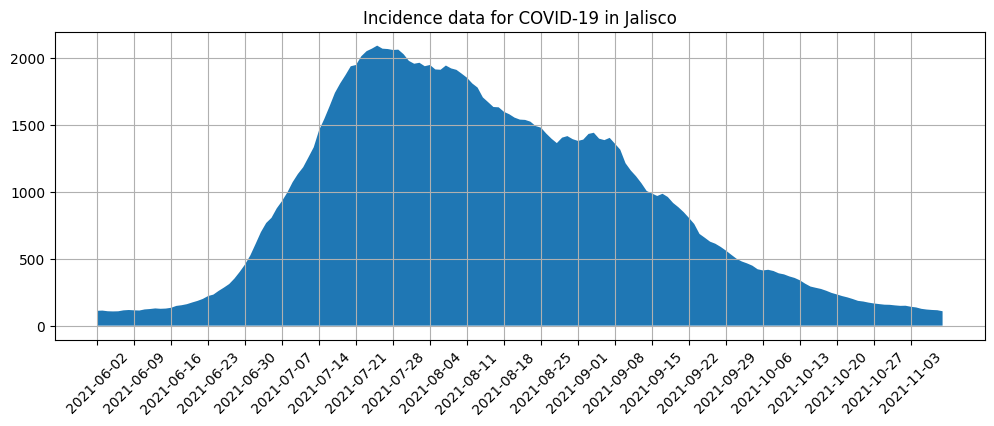

In [3]:
# Loading configuration from configuration file
fname_conf = './configuration_file_test.cfg'

params = parser(fname_conf)

times, data, dates = load_data(params['fname'])

print('Data loaded from file: ', params['fname'])

# plotting data
plt.figure(figsize=(12,4))
plt.fill_between(dates,data, label='Incidence data')
plt.xticks(dates[::7],rotation=45)
plt.title('Incidence data for COVID-19 in Jalisco')
plt.grid()
plt.show()


In [4]:
print(dates[0], dates[-1])
print(np.sum(data))

2021-06-02 2021-11-09
144769.7142857143


In [5]:
# Total population size is taken from the configuration file
N = params["N"]

# Setting initial conditions
E0 = data[0]*5 
I0 = params['I0']
R0 = 0
S0 = N - E0 - I0 - R0

x0 = [S0,E0,I0,R0]

iterations = params['iterations']  # Number of iterations for the MCMC sampler
ndim = 3                           # Dimension of the problem is 3: beta, sigma, gamma

reload_flag = (params['reload'] == 1)
out_file = params['outfile']
outpath = params['outpath']

In [6]:
#### Run this cell in case that are loading a previous run
if reload_flag :
    seir_pyhmc = load(outpath+'/pyhmc/'+out_file)
    seir_pyhmc.outpath = outpath

In [7]:
if not reload_flag :
        seir_pyhmc = SEIR_pyhmc(
                ndim=ndim,
                data=data,
                time=times,
                x0=x0,
                labels=['beta', 'sigma', 'gamma'],
                **params
                )
        
        p0 = np.array([0.36,0.98,0.2])


In [8]:
if not reload_flag :
    ini_time = time()
    seir_pyhmc.run(iterations,p0)
    end_time = time()
    print('Time elapsed: ', end_time-ini_time)

    dump(seir_pyhmc, outpath+'/pyhmc/'+out_file)

  0%|          | 1/10000 [00:03<8:48:55,  3.17s/it]

[0.35788539 0.97465949 0.19944494] -266195.2687311976


  1%|          | 101/10000 [01:19<2:09:19,  1.28it/s]

[0.35795254 0.97453251 0.19967804] -266195.2687311976


  1%|▏         | 136/10000 [01:45<2:04:50,  1.32it/s]/home/abel/seir_uq_methods/samplers/pyhmc.py:171: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  p0 = np.random.multivariate_normal(np.zeros(dim), Weight, 1)
  2%|▏         | 201/10000 [02:35<2:04:49,  1.31it/s]

[0.35330532 0.92970047 0.19459209] -269303.986958046


  3%|▎         | 301/10000 [03:52<2:07:48,  1.26it/s]

[0.34947171 0.89119499 0.18499809] -273565.77113922045


  4%|▍         | 401/10000 [05:09<2:05:43,  1.27it/s]

[0.33395491 0.87129984 0.1812451 ] -277994.7929231206


  5%|▌         | 501/10000 [06:26<2:03:24,  1.28it/s]

[0.34089699 0.88679146 0.17150042] -278916.9227561394


  6%|▌         | 601/10000 [07:42<2:02:25,  1.28it/s]

[0.33664439 0.72672534 0.16693614] -283723.2854952797


  7%|▋         | 701/10000 [08:59<1:57:58,  1.31it/s]

[0.30865271 0.70503651 0.15117632] -292263.2922819567


  8%|▊         | 801/10000 [10:15<2:00:37,  1.27it/s]

[0.30215792 0.69539498 0.14312127] -296247.9338077877


  9%|▉         | 901/10000 [11:32<1:57:10,  1.29it/s]

[0.299131   0.65152858 0.13651916] -300327.8165956465


 10%|█         | 1001/10000 [12:48<1:54:08,  1.31it/s]

[0.31561194 0.65439409 0.12110544] -301459.0683700462


 11%|█         | 1101/10000 [14:06<1:52:52,  1.31it/s]

[0.29580707 0.65118118 0.13481145] -301459.0683700462


 12%|█▏        | 1201/10000 [15:23<1:53:30,  1.29it/s]

[0.34827891 0.66075037 0.09897915] -301459.0683700462


 13%|█▎        | 1301/10000 [16:39<1:49:38,  1.32it/s]

[0.29888919 0.65143464 0.13281637] -301459.0683700462


 14%|█▍        | 1401/10000 [17:57<1:50:27,  1.30it/s]

[0.30038064 0.65183046 0.13172704] -301459.0683700462


 15%|█▌        | 1501/10000 [19:14<1:47:50,  1.31it/s]

[0.29495773 0.65060801 0.13558357] -301459.0683700462


 16%|█▌        | 1601/10000 [20:31<1:47:14,  1.31it/s]

[0.29896113 0.65168563 0.1328582 ] -301459.0683700462


 17%|█▋        | 1701/10000 [21:48<1:48:42,  1.27it/s]

[0.32495825 0.65671839 0.11492729] -301459.0683700462


 18%|█▊        | 1801/10000 [23:04<1:45:09,  1.30it/s]

[0.29167157 0.65037589 0.13759837] -301459.0683700462


 19%|█▉        | 1901/10000 [24:21<1:39:49,  1.35it/s]

[0.33400502 0.65847987 0.10865125] -301459.0683700462


 20%|██        | 2001/10000 [25:38<1:41:52,  1.31it/s]

[0.34635195 0.66044462 0.10029431] -301459.0683700462


 21%|██        | 2101/10000 [26:55<1:43:16,  1.27it/s]

[0.28005696 0.64777127 0.14573271] -301459.0683700462


 22%|██▏       | 2201/10000 [28:13<1:41:20,  1.28it/s]

[0.31002912 0.65349513 0.12517408] -301459.0683700462


 23%|██▎       | 2301/10000 [29:30<1:39:53,  1.28it/s]

[0.31433404 0.65444186 0.12229728] -301459.0683700462


 24%|██▍       | 2401/10000 [30:47<1:34:43,  1.34it/s]

[0.30255391 0.65234753 0.13027078] -301459.0683700462


 25%|██▌       | 2501/10000 [32:05<1:37:00,  1.29it/s]

[0.32546204 0.65666618 0.11462362] -301459.0683700462


 26%|██▌       | 2601/10000 [33:23<1:35:24,  1.29it/s]

[0.28115789 0.6481991  0.14498313] -301459.0683700462


 27%|██▋       | 2701/10000 [34:41<1:33:54,  1.30it/s]

[0.33106419 0.65759241 0.11073311] -301459.0683700462


 28%|██▊       | 2801/10000 [35:58<1:33:47,  1.28it/s]

[0.30529632 0.65279066 0.12851943] -301459.0683700462


 29%|██▉       | 2901/10000 [37:15<1:30:01,  1.31it/s]

[0.3269828  0.65672339 0.11379532] -301459.0683700462


 30%|███       | 3001/10000 [38:33<1:33:03,  1.25it/s]

[0.29698169 0.61206392 0.13439756] -302048.56829523126


 31%|███       | 3101/10000 [39:52<1:30:14,  1.27it/s]

[0.28695762 0.61128661 0.11013192] -309447.519019702


 32%|███▏      | 3201/10000 [41:09<1:24:37,  1.34it/s]

[0.2764888  0.61149237 0.10914208] -312682.37883109547


 33%|███▎      | 3301/10000 [42:27<1:27:00,  1.28it/s]

[0.27353884 0.60628881 0.10727817] -314180.7571674535


 34%|███▍      | 3401/10000 [43:45<1:24:47,  1.30it/s]

[0.2714557  0.60443227 0.1063471 ] -314954.95180796325


 35%|███▌      | 3501/10000 [45:02<1:24:40,  1.28it/s]

[0.27168365 0.60206388 0.10608967] -314954.95180796325


 36%|███▌      | 3601/10000 [46:20<1:23:31,  1.28it/s]

[0.26492027 0.5317335  0.1007898 ] -319670.96026960225


 37%|███▋      | 3701/10000 [47:37<1:22:29,  1.27it/s]

[0.26563693 0.52046689 0.09588183] -320832.3113127863


 38%|███▊      | 3801/10000 [48:55<1:18:13,  1.32it/s]

[0.25674217 0.51591167 0.09398882] -323500.9435544075


 39%|███▉      | 3901/10000 [50:13<1:18:46,  1.29it/s]

[0.2540074  0.48709394 0.09160298] -325442.28839730035


 40%|████      | 4001/10000 [51:31<1:18:30,  1.27it/s]

[0.25065468 0.42948861 0.08696334] -329112.9919741419


 41%|████      | 4101/10000 [52:49<1:14:03,  1.33it/s]

[0.20555175 0.44489018 0.05874569] -343715.56384979805


 42%|████▏     | 4201/10000 [54:07<1:15:43,  1.28it/s]

[0.20059959 0.43887955 0.05572068] -345376.5966595852


 43%|████▎     | 4301/10000 [55:25<1:15:18,  1.26it/s]

[0.18442988 0.44411676 0.05030026] -349631.1603288963


 44%|████▍     | 4401/10000 [56:43<1:11:26,  1.31it/s]

[0.1840337  0.44364604 0.05003547] -349769.9467893659


 45%|████▌     | 4501/10000 [58:00<1:10:39,  1.30it/s]

[0.18398251 0.44470563 0.04995493] -349769.9467893659


 46%|████▌     | 4601/10000 [59:18<1:10:01,  1.28it/s]

[0.18402264 0.44408086 0.05003861] -349769.9467893659


 47%|████▋     | 4701/10000 [1:00:35<1:09:10,  1.28it/s]

[0.18407471 0.44332984 0.05009654] -349769.9467893659


 48%|████▊     | 4801/10000 [1:01:52<1:07:51,  1.28it/s]

[0.18399149 0.44332538 0.05002297] -349769.9467893659


 49%|████▉     | 4901/10000 [1:03:10<1:06:16,  1.28it/s]

[0.18403609 0.44334295 0.05001353] -349769.9467893659


 50%|█████     | 5001/10000 [1:04:28<1:06:59,  1.24it/s]

[0.18401999 0.44363446 0.05001095] -349769.9467893659


 51%|█████     | 5101/10000 [1:05:48<1:04:55,  1.26it/s]

[0.1839559  0.44444934 0.04999204] -349769.9467893659


 52%|█████▏    | 5201/10000 [1:07:06<1:03:45,  1.25it/s]

[0.18403266 0.44279874 0.05015943] -349769.9467893659


 53%|█████▎    | 5301/10000 [1:08:25<1:02:56,  1.24it/s]

[0.18403871 0.44397149 0.05007003] -349769.9467893659


 54%|█████▍    | 5401/10000 [1:09:43<58:55,  1.30it/s]  

[0.18392938 0.44455126 0.0498985 ] -349769.9467893659


 55%|█████▌    | 5501/10000 [1:11:01<59:02,  1.27it/s]  

[0.18401939 0.44357654 0.04999282] -349769.9467893659


 56%|█████▌    | 5601/10000 [1:12:20<58:47,  1.25it/s]  

[0.18328749 0.44420786 0.04930653] -349964.26694609533


 57%|█████▋    | 5701/10000 [1:13:39<54:35,  1.31it/s]

[0.18279956 0.44398878 0.04904009] -350093.2257365071


 58%|█████▊    | 5801/10000 [1:14:58<53:18,  1.31it/s]

[0.18009344 0.38827203 0.04862593] -351591.1165065829


 59%|█████▉    | 5901/10000 [1:16:16<53:12,  1.28it/s]

[0.18001035 0.3864755  0.04721696] -351818.3883892392


 60%|██████    | 6001/10000 [1:17:36<49:46,  1.34it/s]

[0.17999027 0.38625991 0.04725138] -351837.1345094989


 61%|██████    | 6101/10000 [1:18:53<50:32,  1.29it/s]

[0.17971358 0.38756281 0.04707955] -351885.030504207


 62%|██████▏   | 6201/10000 [1:20:11<49:32,  1.28it/s]

[0.17987207 0.38455627 0.04693701] -351905.76166155067


 63%|██████▎   | 6301/10000 [1:21:29<45:31,  1.35it/s]

[0.17603004 0.39275706 0.04422775] -352686.67679586203


 64%|██████▍   | 6401/10000 [1:22:48<47:05,  1.27it/s]

[0.19059673 0.37160661 0.04317639] -352702.3061082615


 65%|██████▌   | 6501/10000 [1:24:07<46:08,  1.26it/s]

[0.1835334  0.3942272  0.04374998] -352702.3061082615


 66%|██████▌   | 6601/10000 [1:25:26<44:36,  1.27it/s]

[0.16393981 0.39276241 0.04090776] -354527.61325414444


 67%|██████▋   | 6701/10000 [1:26:45<44:02,  1.25it/s]

[0.16221056 0.39117161 0.03946304] -354965.89911158575


 68%|██████▊   | 6801/10000 [1:28:04<41:10,  1.30it/s]

[0.16201249 0.39251423 0.03920142] -355036.9369336878


 69%|██████▉   | 6901/10000 [1:29:22<40:55,  1.26it/s]

[0.16201485 0.39243217 0.03920799] -355036.9369336878


 70%|███████   | 7001/10000 [1:30:41<37:35,  1.33it/s]

[0.16201923 0.39102724 0.03910833] -355036.9369336878


 71%|███████   | 7101/10000 [1:31:59<38:17,  1.26it/s]

[0.16206616 0.39176512 0.03912152] -355036.9369336878


 72%|███████▏  | 7201/10000 [1:33:18<35:25,  1.32it/s]

[0.16091656 0.39007503 0.03828757] -355044.88210848643


 73%|███████▎  | 7301/10000 [1:34:38<35:59,  1.25it/s]

[0.16059536 0.38952132 0.03801319] -355331.3657058699


 74%|███████▍  | 7401/10000 [1:35:58<34:30,  1.26it/s]

[0.16046063 0.3888237  0.0376424 ] -355443.528462025


 75%|███████▌  | 7501/10000 [1:37:17<33:33,  1.24it/s]

[0.16048529 0.38881256 0.03765353] -355443.528462025


 76%|███████▌  | 7601/10000 [1:38:36<31:50,  1.26it/s]

[0.16047381 0.38883975 0.03764513] -355443.528462025


 77%|███████▋  | 7701/10000 [1:39:56<29:58,  1.28it/s]

[0.16048031 0.38879867 0.03764708] -355443.528462025


 78%|███████▊  | 7801/10000 [1:41:14<28:33,  1.28it/s]

[0.16047214 0.38883389 0.03763935] -355443.528462025


 79%|███████▉  | 7901/10000 [1:42:34<28:04,  1.25it/s]

[0.16048955 0.38921585 0.03766325] -355441.5158372308


 80%|████████  | 8001/10000 [1:43:54<27:38,  1.21it/s]

[0.1604776  0.38860671 0.03764244] -355441.5158372308


 81%|████████  | 8101/10000 [1:45:13<24:36,  1.29it/s]

[0.16046519 0.38903615 0.03765065] -355441.5158372308


 82%|████████▏ | 8201/10000 [1:46:32<22:28,  1.33it/s]

[0.16048924 0.38886484 0.03765286] -355441.5158372308


 83%|████████▎ | 8301/10000 [1:47:51<22:31,  1.26it/s]

[0.16050665 0.3884329  0.03765544] -355443.528462025


 84%|████████▍ | 8401/10000 [1:49:11<21:39,  1.23it/s]

[0.16045767 0.38835147 0.03761793] -355443.528462025


 85%|████████▌ | 8501/10000 [1:50:29<20:02,  1.25it/s]

[0.16044563 0.38886772 0.03763106] -355443.528462025


 86%|████████▌ | 8601/10000 [1:51:49<18:39,  1.25it/s]

[0.16049249 0.38856786 0.03765494] -355443.528462025


 87%|████████▋ | 8701/10000 [1:53:09<17:25,  1.24it/s]

[0.16048327 0.38872039 0.03765749] -355443.528462025


 88%|████████▊ | 8801/10000 [1:54:28<15:38,  1.28it/s]

[0.15936764 0.38572634 0.03651757] -355674.87159664324


 89%|████████▉ | 8901/10000 [1:55:48<14:18,  1.28it/s]

[0.15936231 0.38582395 0.03644462] -355726.21944812377


 90%|█████████ | 9001/10000 [1:57:07<13:20,  1.25it/s]

[0.15935274 0.38584555 0.03642959] -355726.21944812377


 91%|█████████ | 9101/10000 [1:58:26<11:36,  1.29it/s]

[0.15935197 0.38573527 0.03643677] -355726.21944812377


 92%|█████████▏| 9201/10000 [1:59:47<10:28,  1.27it/s]

[0.15935533 0.38586134 0.03644653] -355726.21944812377


 93%|█████████▎| 9301/10000 [2:01:07<09:17,  1.25it/s]

[0.15935159 0.38582744 0.03643662] -355726.21944812377


 94%|█████████▍| 9401/10000 [2:02:27<07:50,  1.27it/s]

[0.15933149 0.38536584 0.03641173] -355733.1022404617


 95%|█████████▌| 9501/10000 [2:03:47<06:44,  1.23it/s]

[0.15788666 0.32593099 0.03376199] -356717.0726402139


 96%|█████████▌| 9601/10000 [2:05:08<05:27,  1.22it/s]

[0.15699935 0.32937881 0.03360002] -356972.0547718968


 97%|█████████▋| 9701/10000 [2:06:30<04:07,  1.21it/s]

[0.15696464 0.32939935 0.03359309] -356972.0547718968


 98%|█████████▊| 9801/10000 [2:07:50<02:40,  1.24it/s]

[0.1569801  0.32921356 0.03358596] -356975.9386615983


 99%|█████████▉| 9901/10000 [2:09:10<01:20,  1.23it/s]

[0.15699385 0.32928796 0.03360269] -356977.78117163666


100%|██████████| 10000/10000 [2:10:30<00:00,  1.28it/s]

Time elapsed:  7830.372466802597


In [14]:
print(seir_pyhmc.Output.shape)
print(seir_pyhmc.Outputp.shape)

(10001, 4)
(10001, 4)


In [ ]:
#seir_pyhmc.instance = 'pyhmc'
seir_pyhmc.create_dictionary()

In [19]:
seir_pyhmc.summary()


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.222  0.066   0.157    0.335      0.041    0.008       3.0      29.0   
sigma  0.508  0.153   0.329    0.727      0.087    0.027       3.0      29.0   
gamma  0.080  0.048   0.034    0.169      0.029    0.007       3.0      29.0   

       r_hat  
beta    1.81  
sigma   1.76  
gamma   1.82  


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.222  0.066   0.157    0.335      0.041    0.008       3.0      29.0   
sigma  0.508  0.153   0.329    0.727      0.087    0.027       3.0      29.0   
gamma  0.080  0.048   0.034    0.169      0.029    0.007       3.0      29.0   

       r_hat  
beta    1.81  
sigma   1.76  
gamma   1.82  


<Figure size 640x480 with 0 Axes>

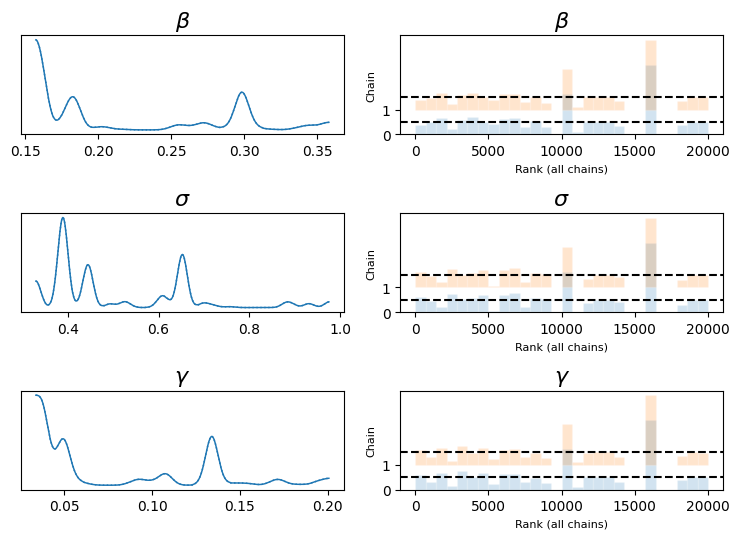

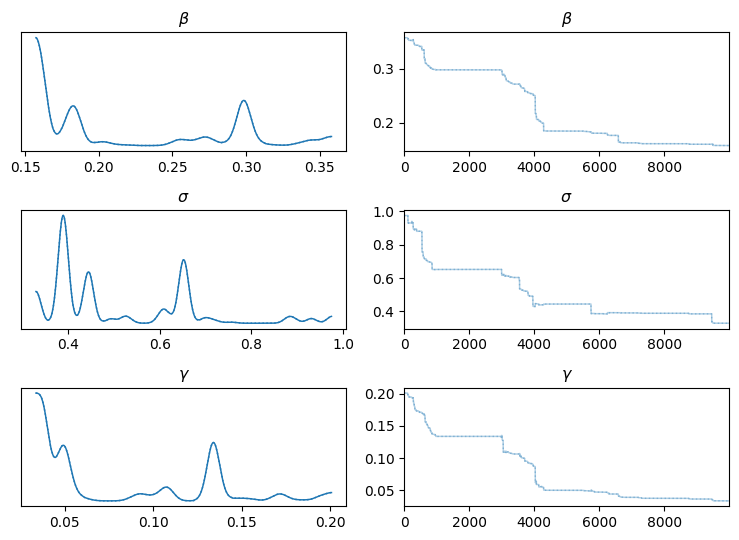

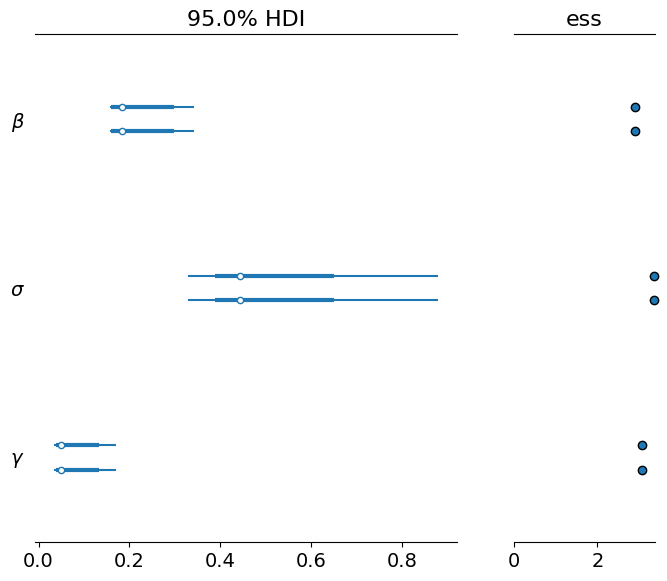

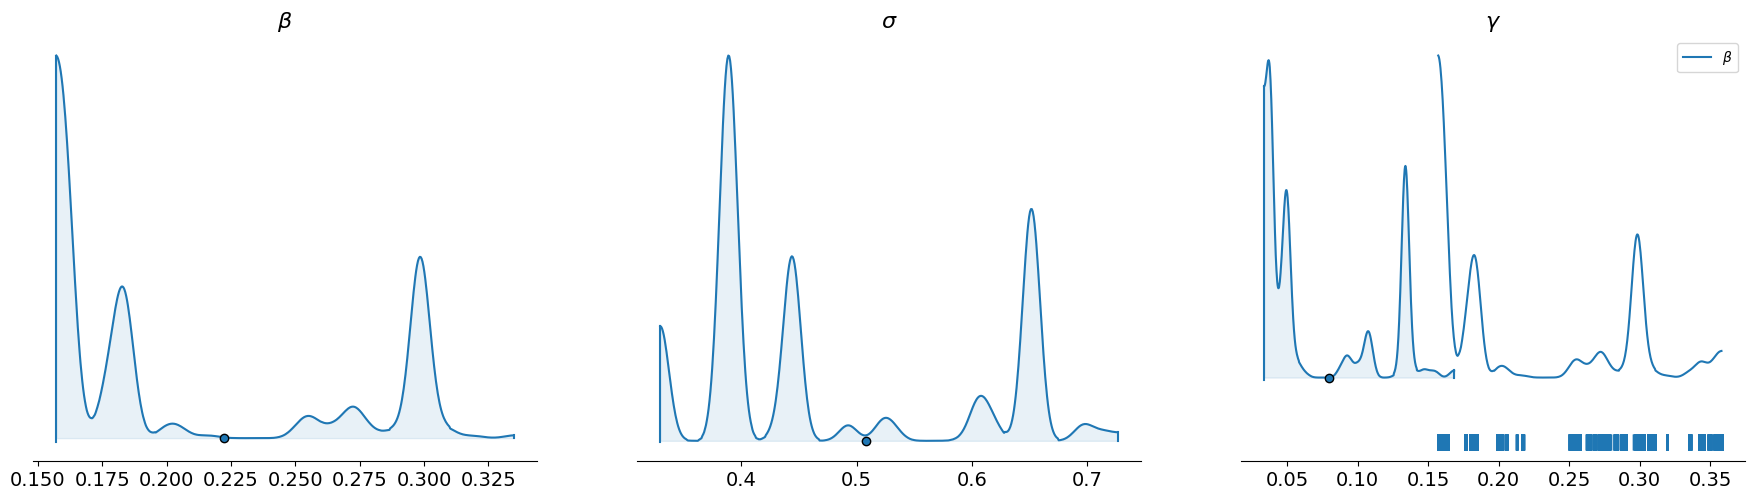

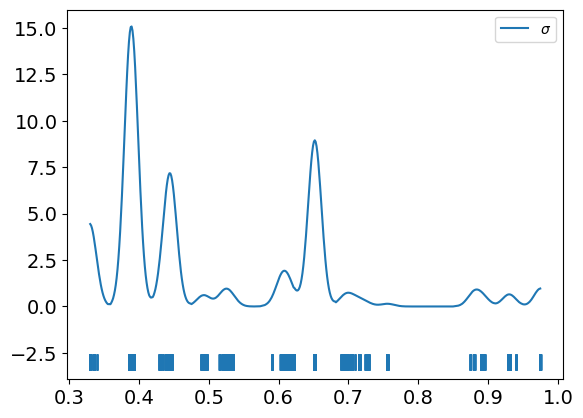

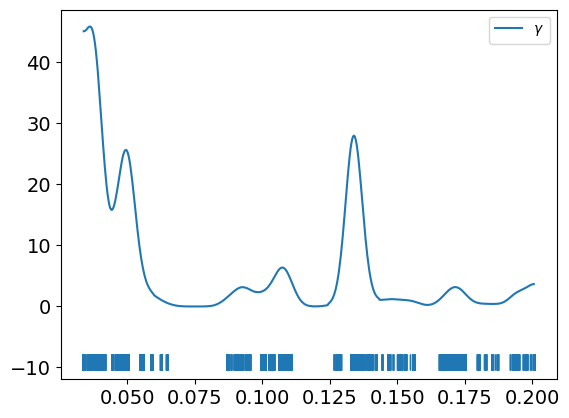

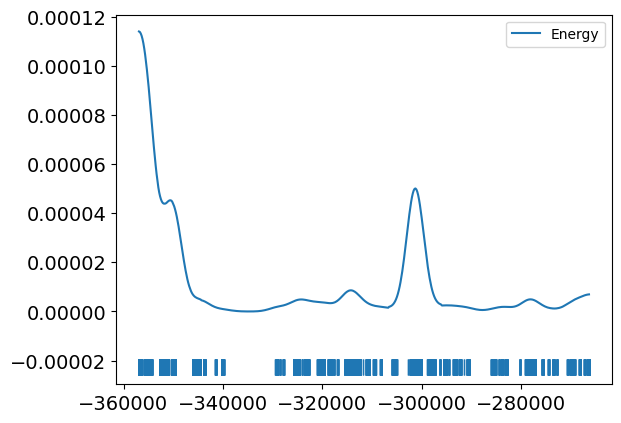

Generating 10 prior samples. Prior model: Gamma
Generating prior curves. Prior model: Gamma


/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/hom

Using 5000 samples


100%|██████████| 10000/10000 [03:07<00:00, 53.37it/s]
/home/abel/seir_uq_methods/utils/AnalysisTools.py:469: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(self.outpath+'/'+self.instance+'/'+self.instance+'_probability_region.png',dpi=300)


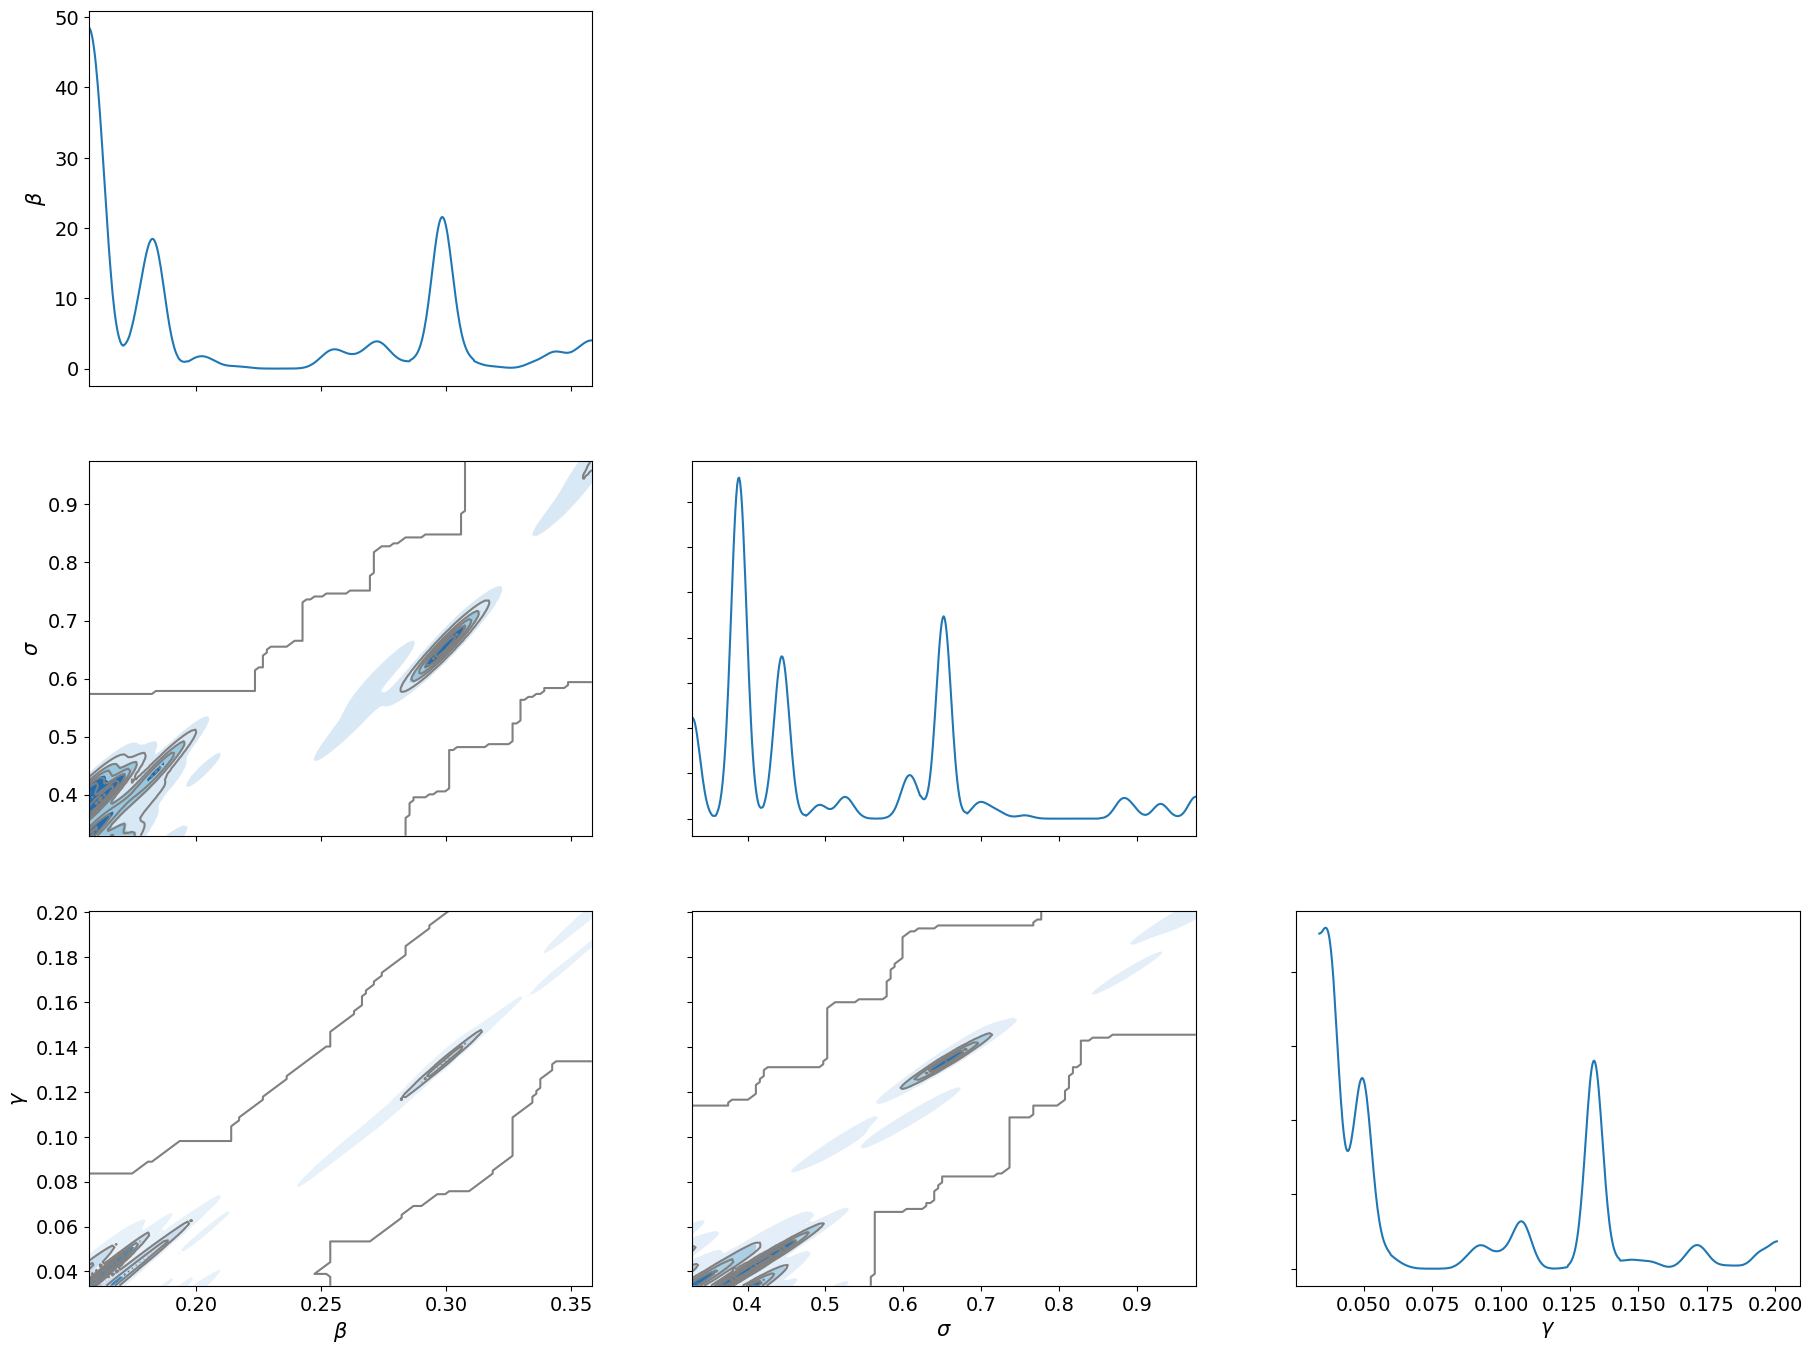

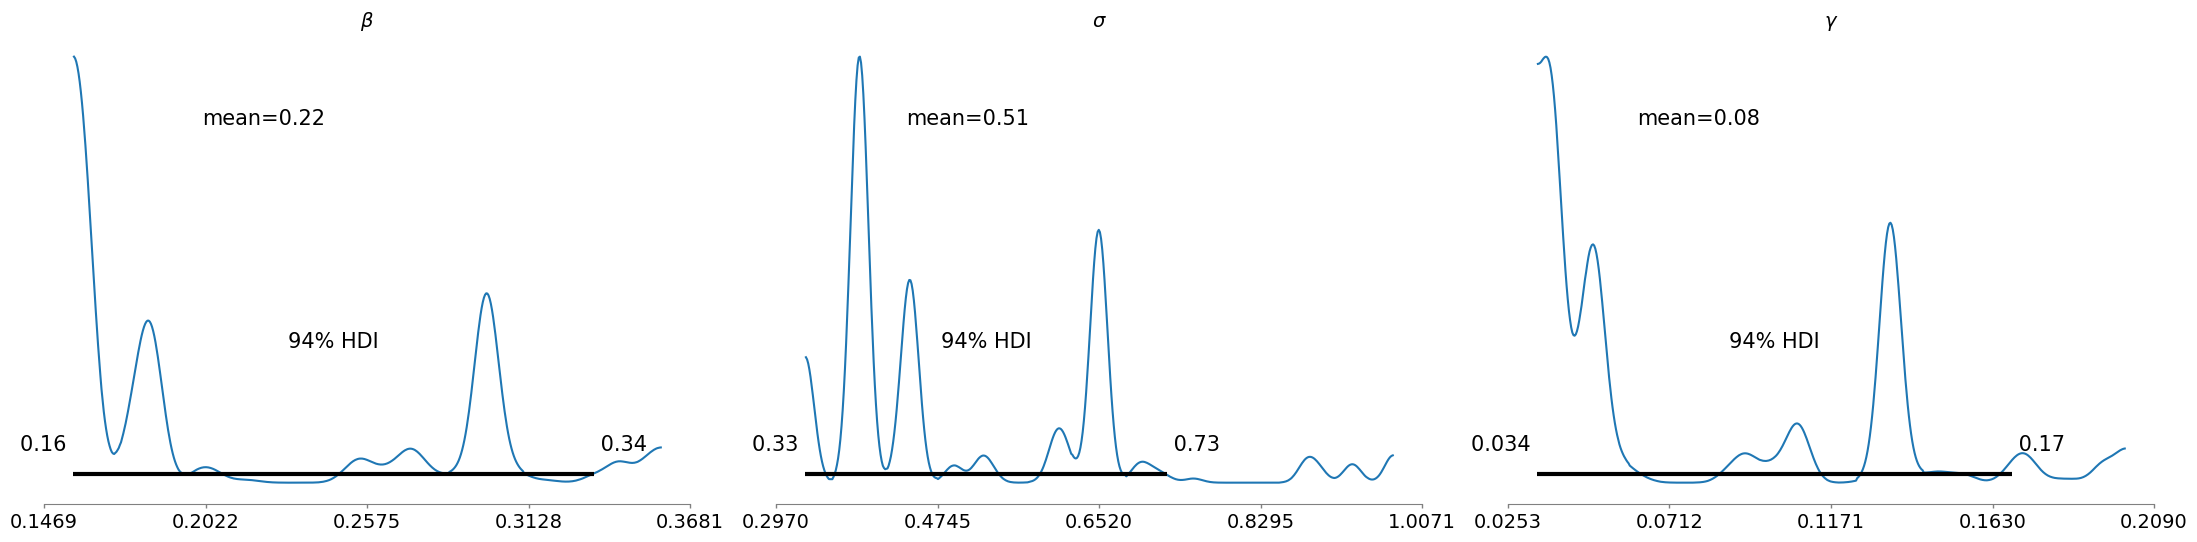

/opt/conda/envs/bnn-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


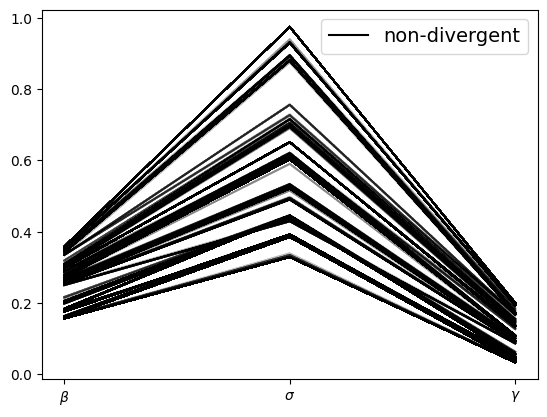

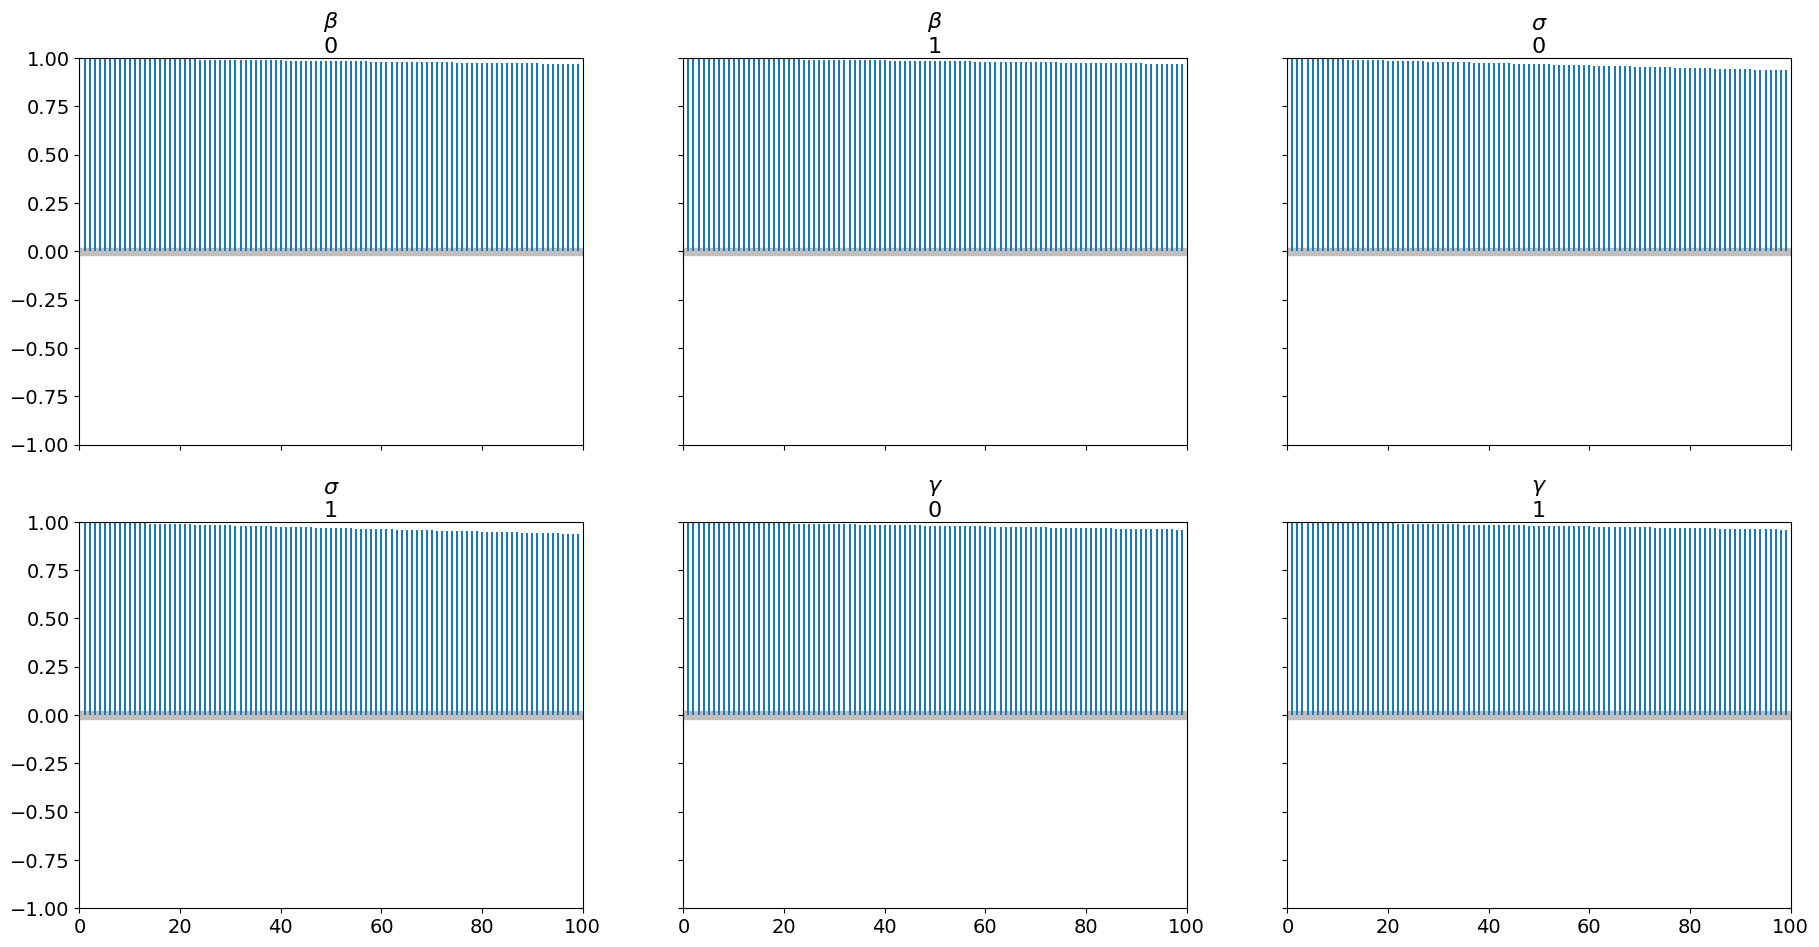

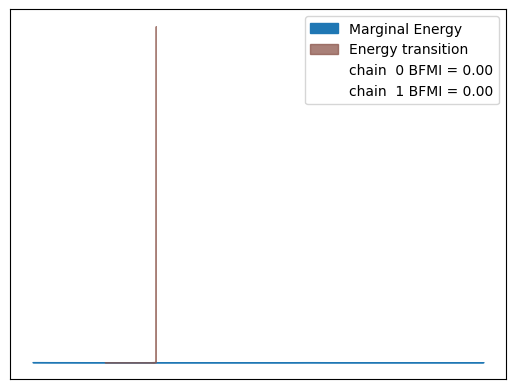

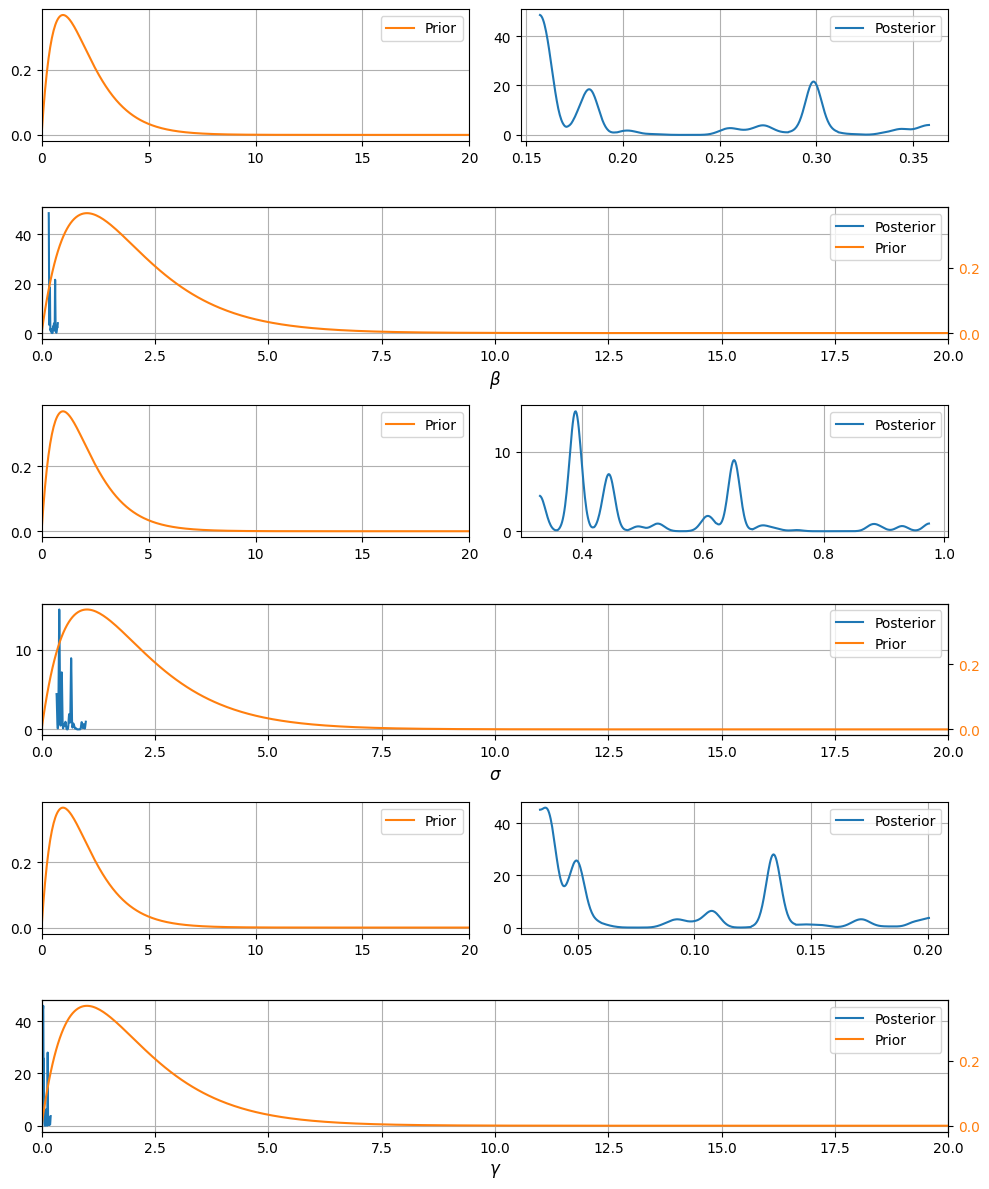

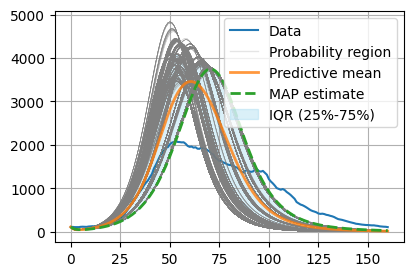

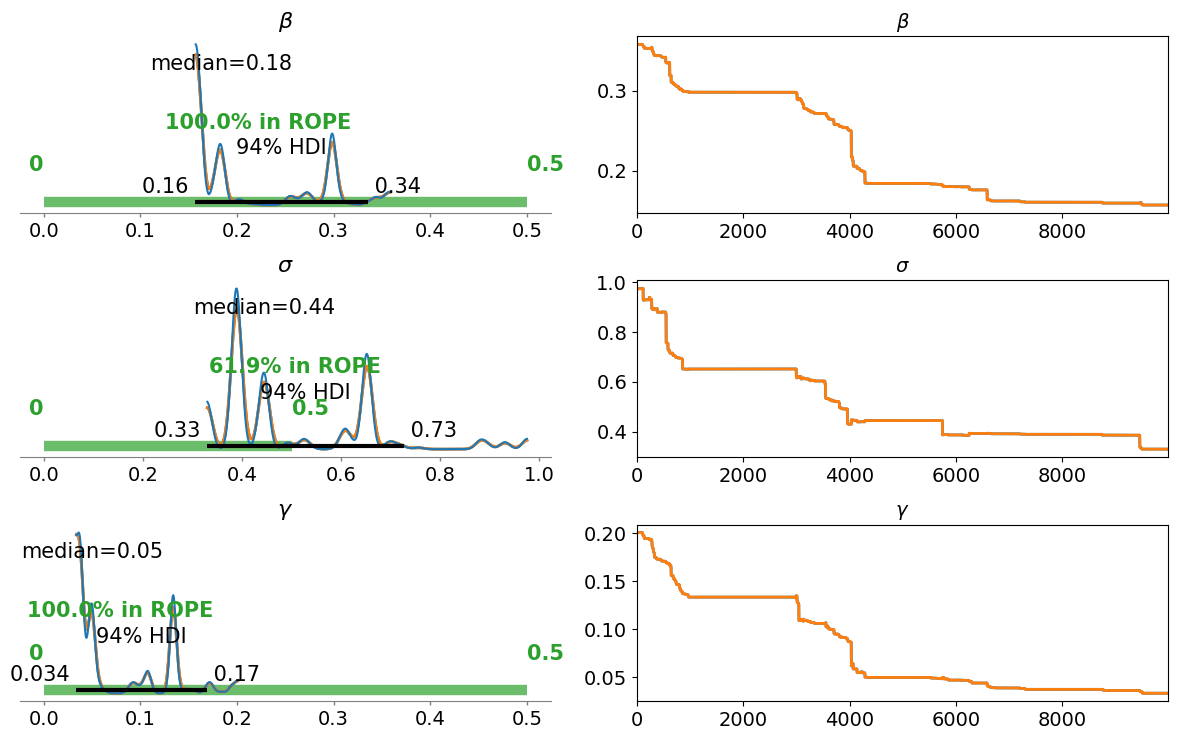

In [20]:

seir_pyhmc.report_results()

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.210  0.057   0.159    0.298      0.033    0.008       3.0      29.0   
sigma  0.474  0.112   0.340    0.652      0.064    0.016       3.0      30.0   
gamma  0.070  0.040   0.035    0.134      0.022    0.006       3.0      29.0   

       r_hat  
beta    1.95  
sigma   1.87  
gamma   1.94  


<Figure size 640x480 with 0 Axes>

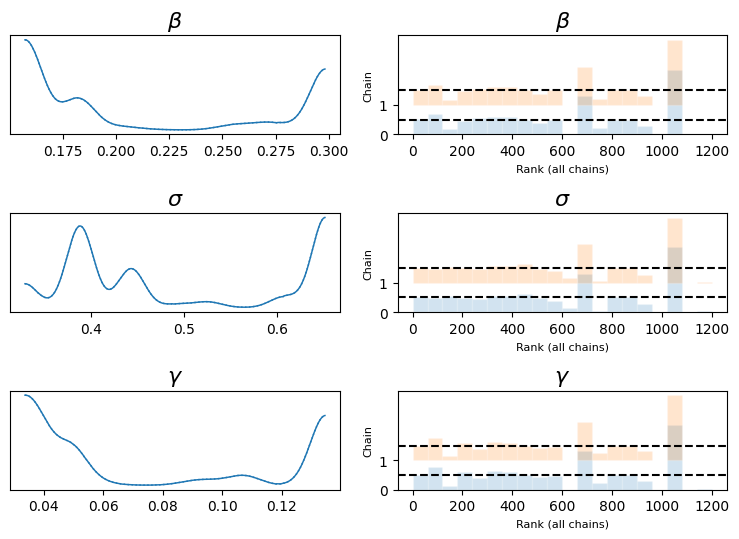

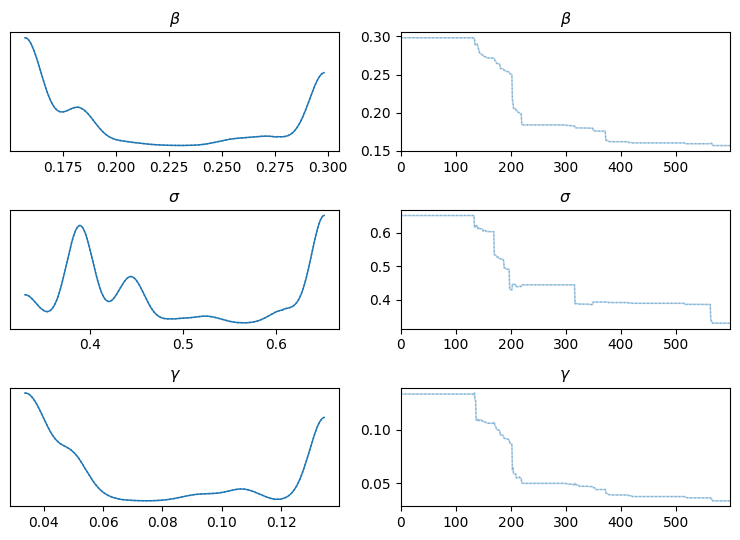

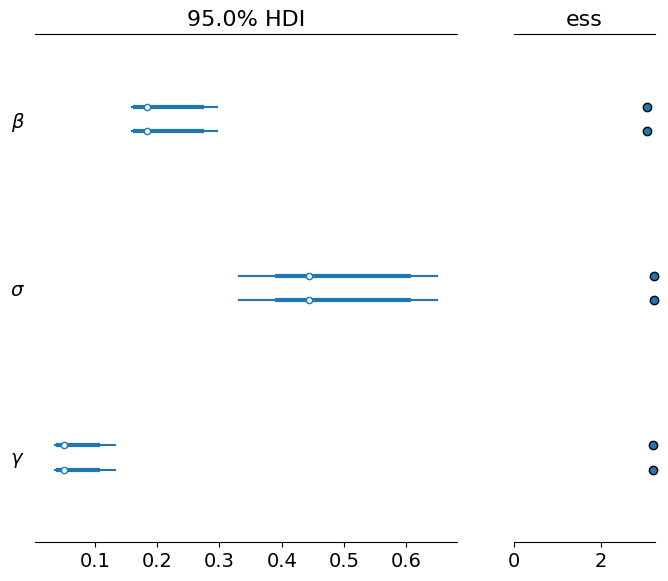

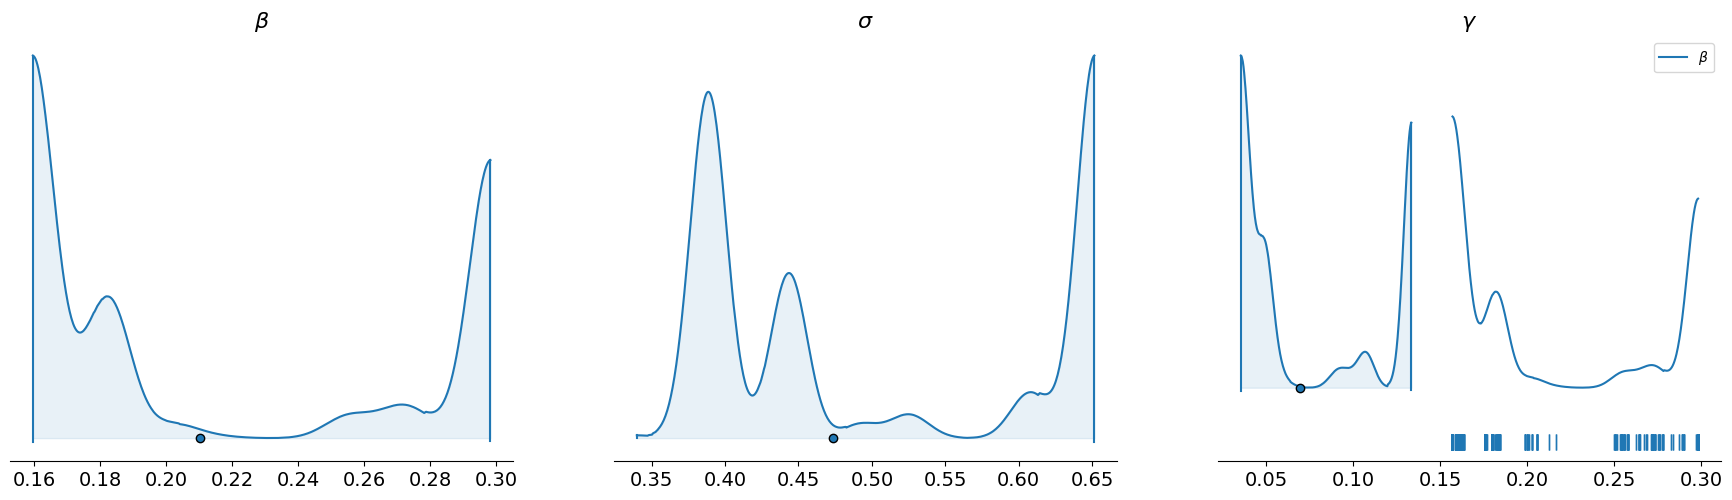

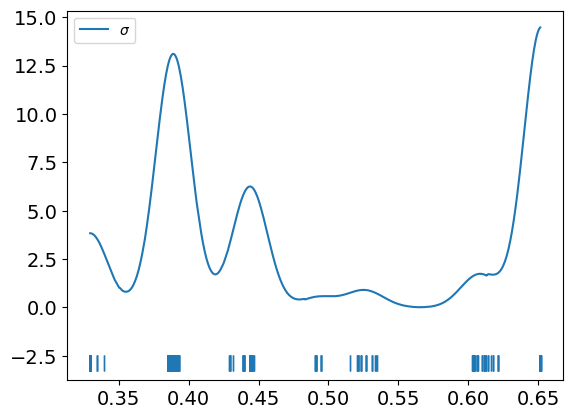

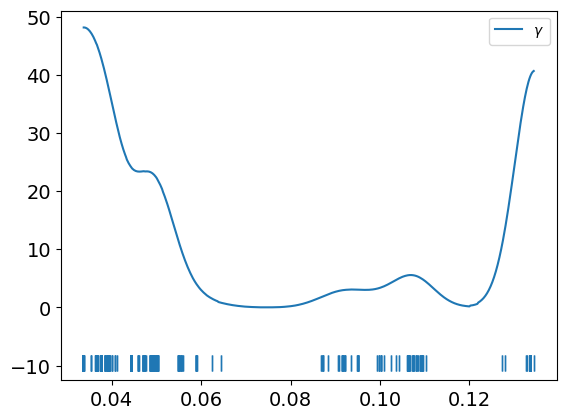

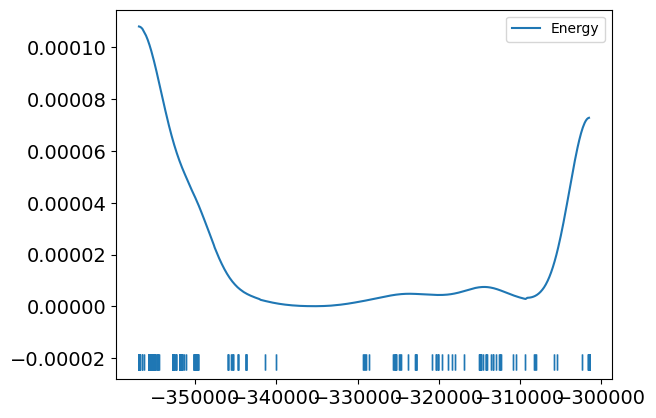

Generating 10 prior samples. Prior model: Gamma
Generating prior curves. Prior model: Gamma


/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/hom

Using 300 samples


100%|██████████| 600/600 [00:11<00:00, 53.80it/s]


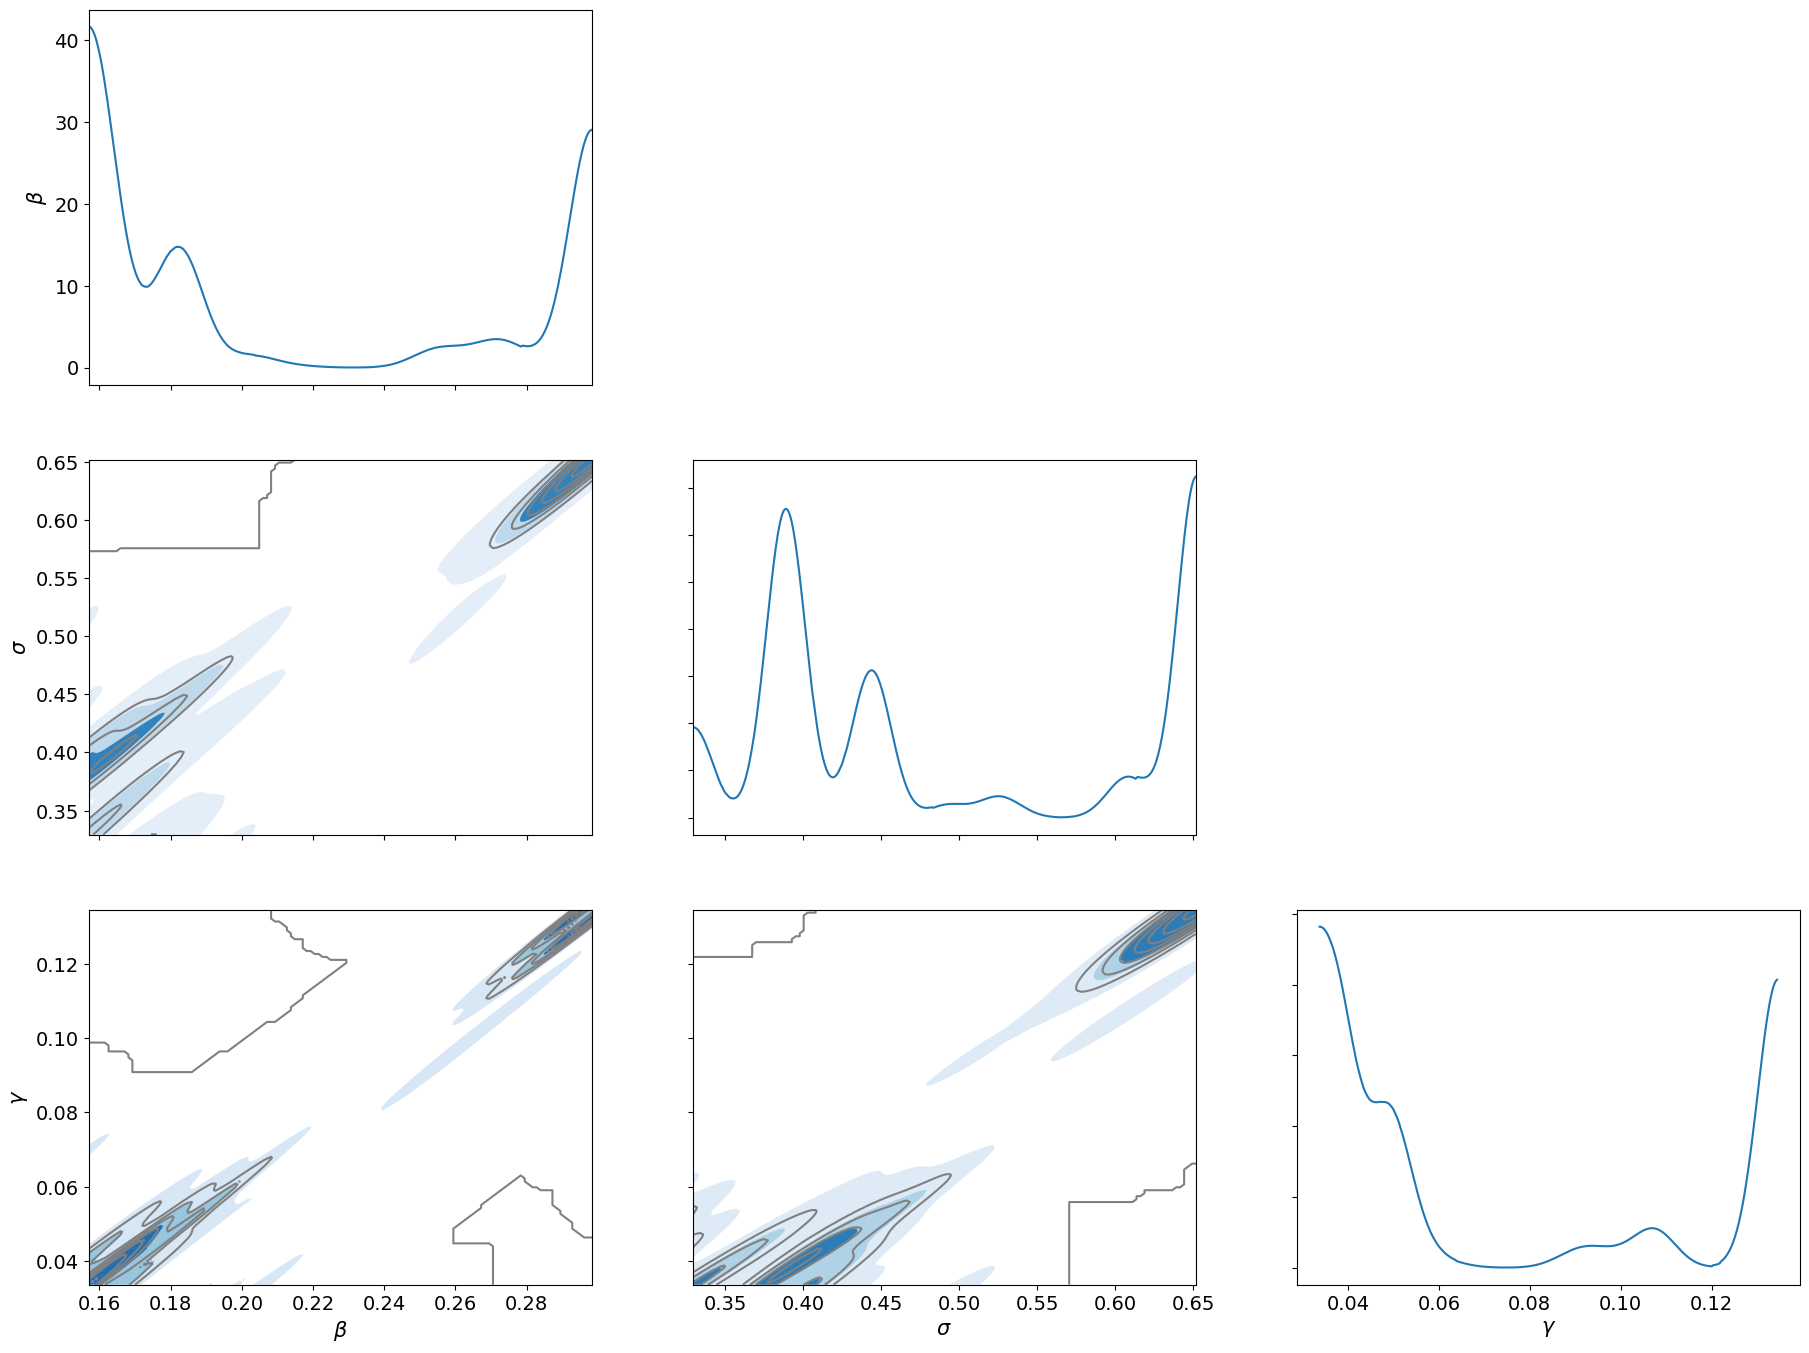

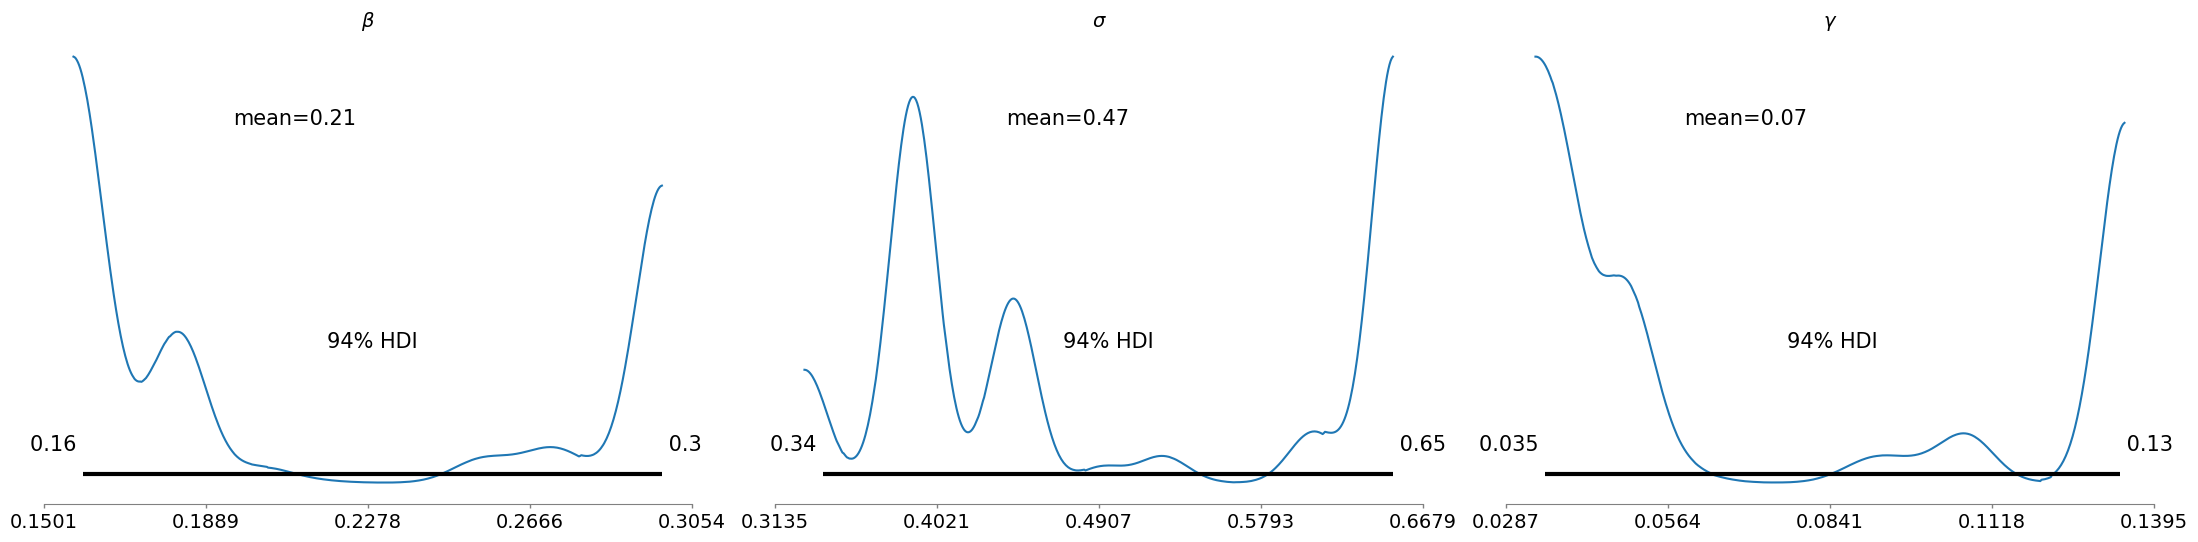

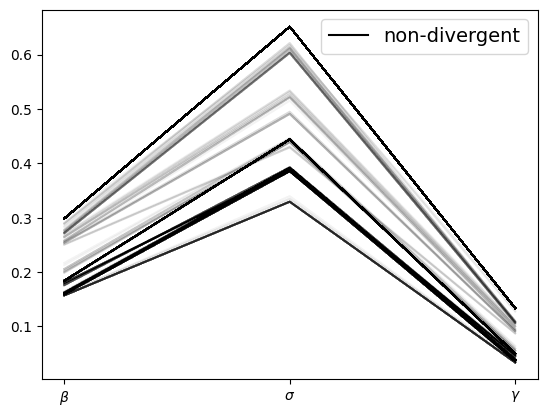

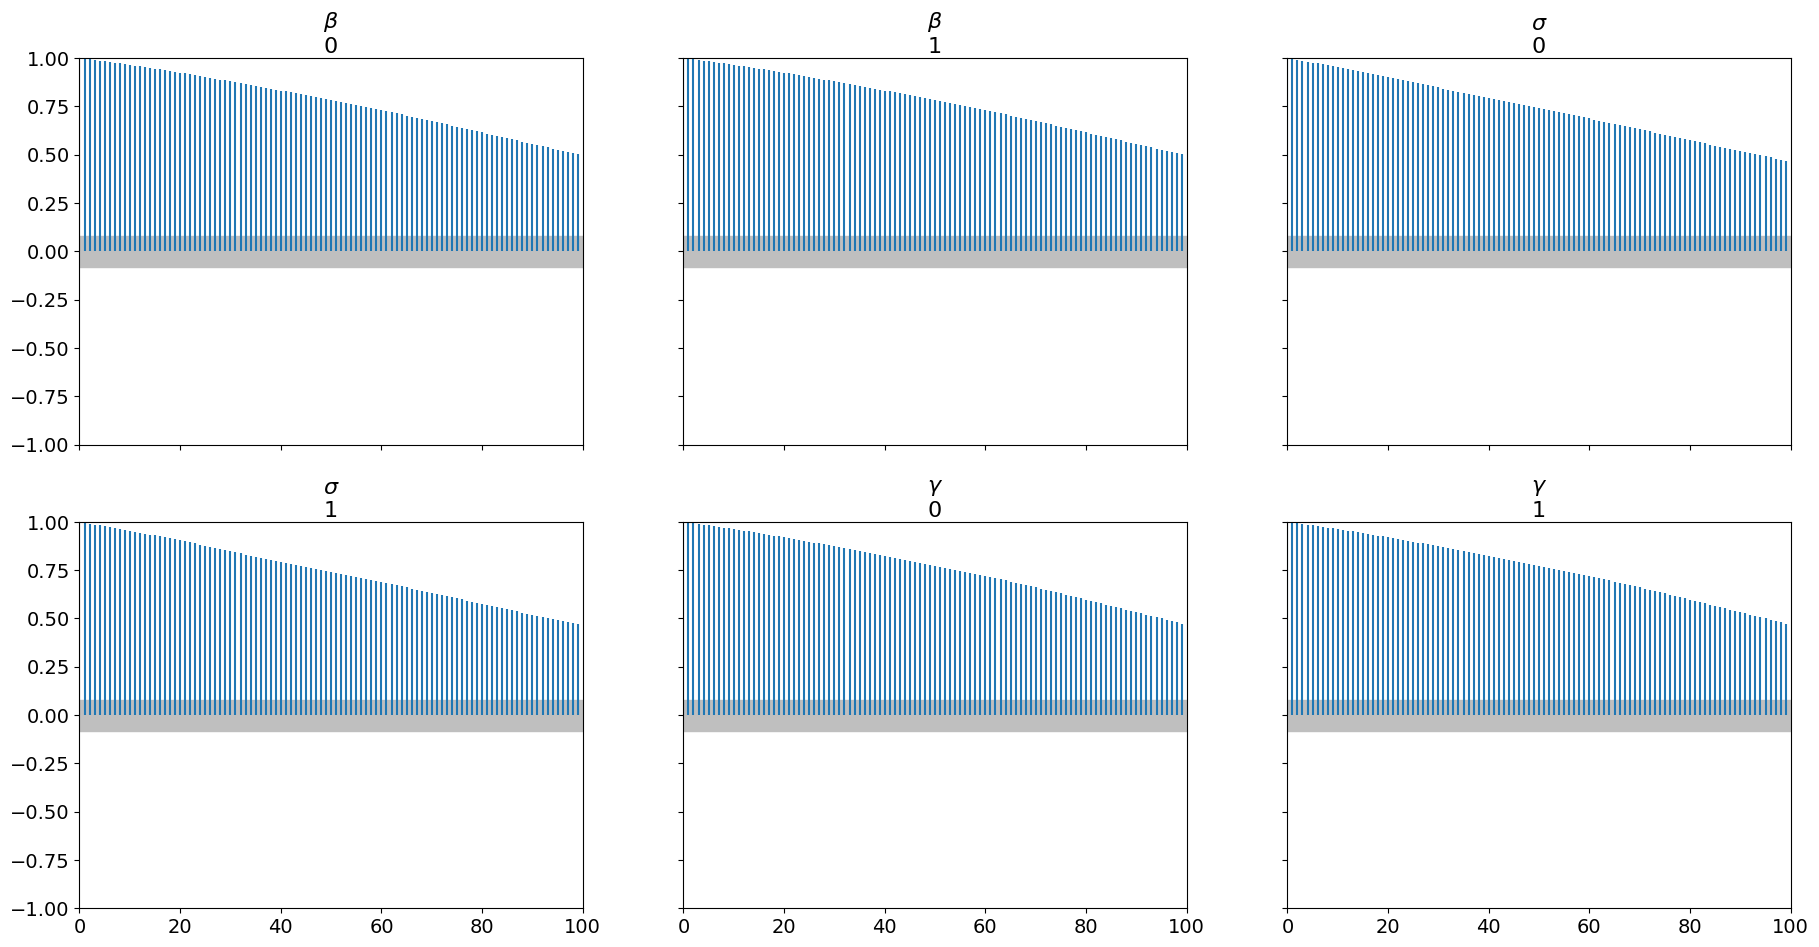

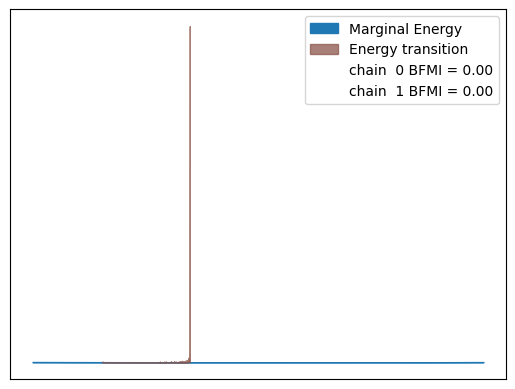

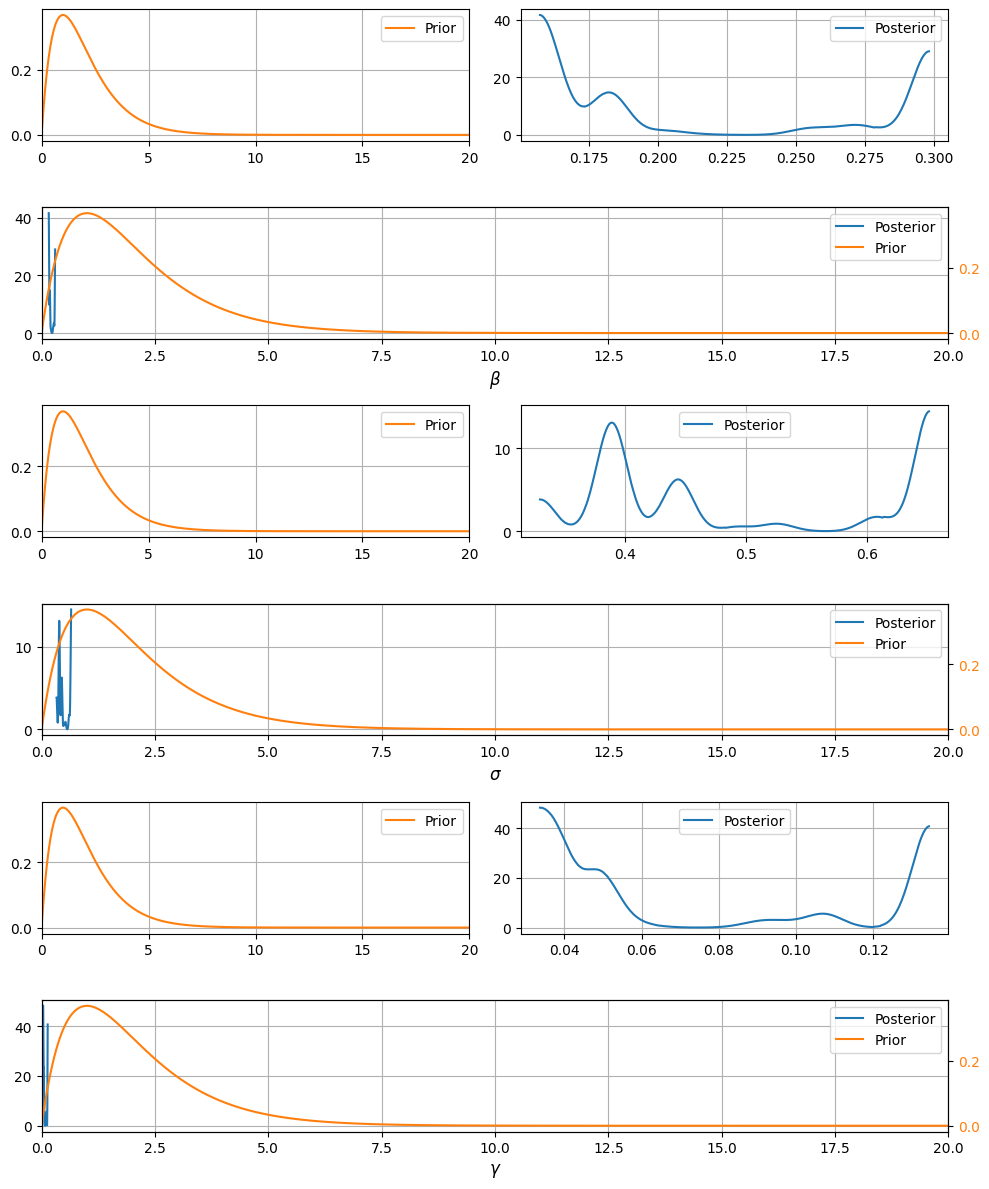

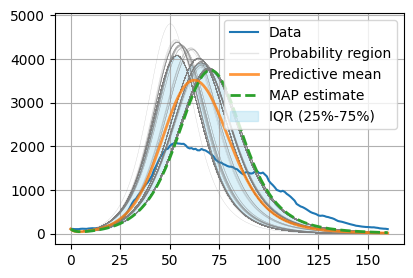

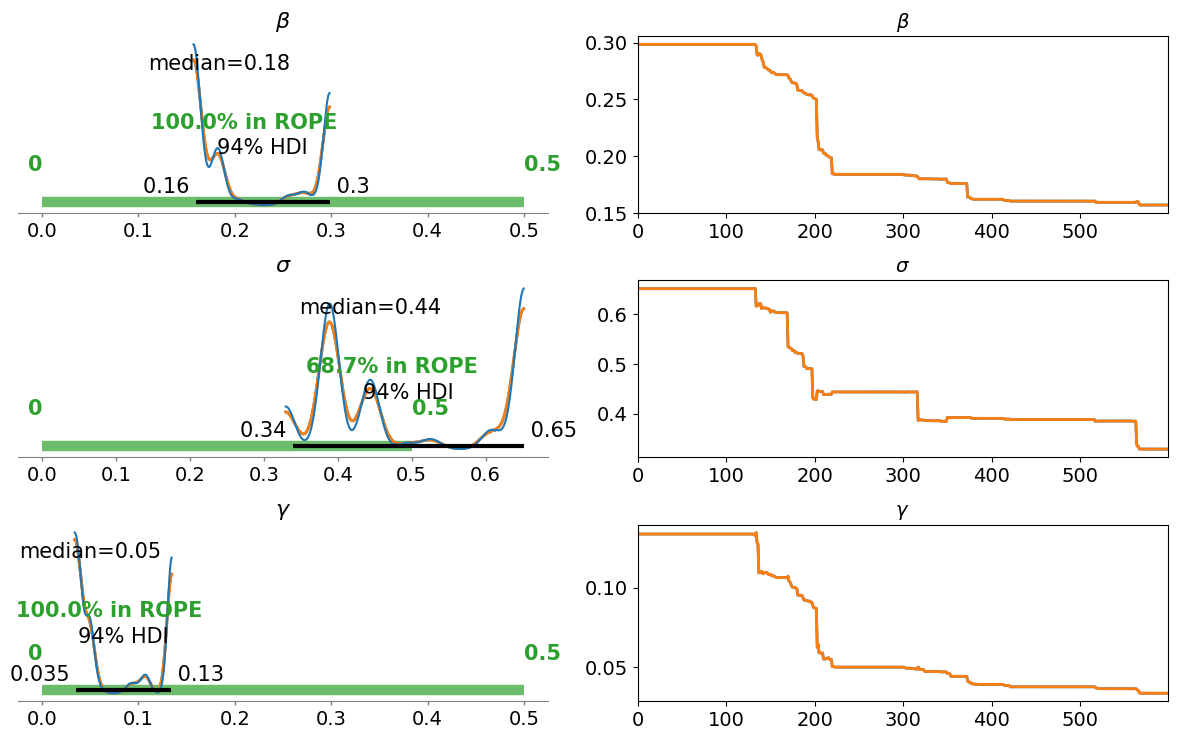

In [21]:
seir_pyhmc.create_dictionary(burnin=1000, subsample=15)

seir_pyhmc.report_results()